# 03 — Critical Path Analysis


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from build_optimiser.config import Config
from build_optimiser.graph import load_graph, attach_metrics
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

cfg = Config.from_yaml('../config.yaml')
file_df = pd.read_parquet('../data/processed/file_metrics.parquet')
target_df = pd.read_parquet('../data/processed/target_metrics.parquet')
edge_df = pd.read_parquet('../data/processed/edge_list.parquet')
G = load_graph('../data/processed/edge_list.parquet')
attach_metrics(G, target_df)

%matplotlib inline
sns.set_theme(style='whitegrid')

## Compute Critical Path

Longest weighted path: codegen_time + compile_time_max + archive/link time.


In [2]:
# Compute effective weight per node: the wall-clock cost of building one target
# Uses compile_time_max_ms (not sum) because files within a target compile in parallel
weight_attr = 'effective_weight'
for n in G.nodes():
    nd = G.nodes[n]
    G.nodes[n][weight_attr] = (
        (nd.get('codegen_time_ms') or 0)
        + (nd.get('compile_time_max_ms') or 0)
        + (nd.get('archive_time_ms') or 0)
        + (nd.get('link_time_ms') or 0)
    )

# Forward DP in build order (dependencies before dependants).
# Convention: A -> B means "A depends on B", so topological sort yields
# dependants before dependencies. Reverse it to get build order.
topo = list(nx.topological_sort(G))

earliest_finish = {}
predecessor_on_path = {}

for n in reversed(topo):  # build order: dependencies first
    w = G.nodes[n][weight_attr]
    deps = list(G.successors(n))  # what n depends on
    if not deps:
        earliest_finish[n] = w
        predecessor_on_path[n] = None
    else:
        best_dep = max(deps, key=lambda d: earliest_finish[d])
        earliest_finish[n] = earliest_finish[best_dep] + w
        predecessor_on_path[n] = best_dep

# Reconstruct the critical path
cp_end = max(earliest_finish, key=earliest_finish.get)
cp_length = earliest_finish[cp_end]

path = []
node = cp_end
while node is not None:
    path.append(node)
    node = predecessor_on_path[node]
cp_nodes = path
cp_set = set(cp_nodes)

# Display
cp_df = pd.DataFrame({
    'target': cp_nodes,
    'effective_weight_ms': [G.nodes[n][weight_attr] for n in cp_nodes],
    'earliest_finish_ms': [earliest_finish[n] for n in cp_nodes],
    'target_type': [G.nodes[n].get('target_type', '') for n in cp_nodes],
})

print(f"Critical path length: {cp_length:,} ms")
print(f"Critical path targets: {len(cp_nodes)}")
display(cp_df)

Critical path length: 8,575 ms
Critical path targets: 8


,target,effective_weight_ms,earliest_finish_ms,target_type
0,app,811,8575,EXECUTABLE
1,engine,821,7764,STATIC_LIBRARY
2,middleware,1030,6943,STATIC_LIBRARY
3,compute,948,5913,STATIC_LIBRARY
4,math_lib,3015,4965,STATIC_LIBRARY
5,math_objs,523,1950,OBJECT_LIBRARY
6,core,1427,1427,STATIC_LIBRARY
7,config_iface,0,0,INTERFACE_LIBRARY


## Critical Path with Codegen

Account for codegen steps that must complete before compilation.


Codegen-gated targets on critical path: 0
Codegen time on critical path: 0 ms (0.0% of CP length)


,target,codegen_ms,compile_max_ms,archive_ms,link_ms,total_ms,codegen_gated
0,app,0,763,0,48,811,False
1,engine,0,783,38,0,821,False
2,middleware,0,984,46,0,1030,False
3,compute,0,906,42,0,948,False
4,math_lib,0,2969,46,0,3015,False
5,math_objs,0,523,0,0,523,False
6,core,0,1287,140,0,1427,False
7,config_iface,0,0,0,0,0,False


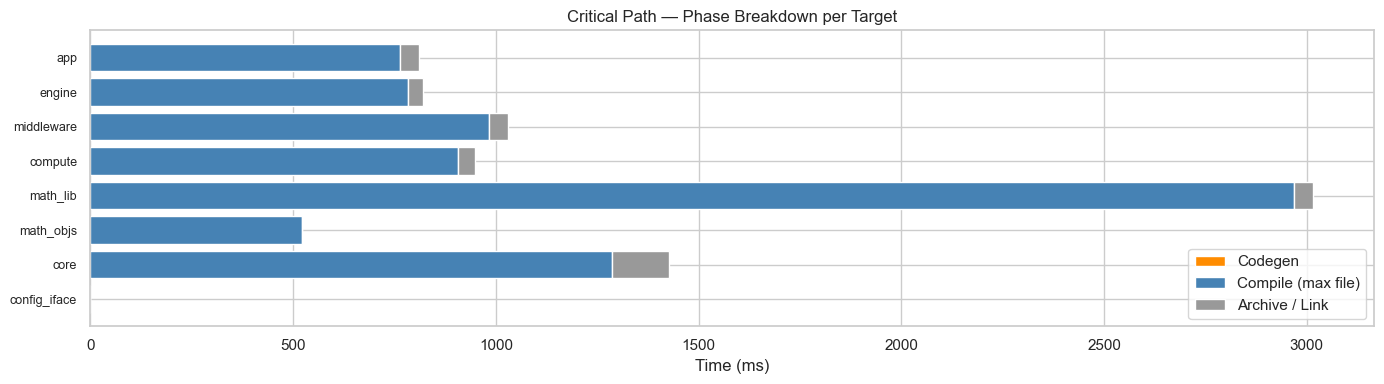

In [3]:
# The weight formula already includes codegen_time_ms, so the critical path
# computed above correctly accounts for codegen gating compilation.
# Break down each CP target into its component phases.

cp_codegen_gated = [n for n in cp_nodes if (G.nodes[n].get('codegen_time_ms') or 0) > 0]

breakdown = []
for n in cp_nodes:
    nd = G.nodes[n]
    breakdown.append({
        'target': n,
        'codegen_ms': nd.get('codegen_time_ms') or 0,
        'compile_max_ms': nd.get('compile_time_max_ms') or 0,
        'archive_ms': nd.get('archive_time_ms') or 0,
        'link_ms': nd.get('link_time_ms') or 0,
        'total_ms': nd.get(weight_attr, 0),
        'codegen_gated': n in cp_codegen_gated,
    })
breakdown_df = pd.DataFrame(breakdown)

cp_codegen_total = breakdown_df['codegen_ms'].sum()
print(f"Codegen-gated targets on critical path: {len(cp_codegen_gated)}")
print(f"Codegen time on critical path: {cp_codegen_total:,} ms "
      f"({cp_codegen_total / cp_length:.1%} of CP length)")
display(breakdown_df)

# Stacked horizontal bar: phase breakdown per CP target
fig, ax = plt.subplots(figsize=(14, max(4, len(cp_nodes) * 0.5)))
targets = breakdown_df['target']
y = range(len(targets))

ax.barh(y, breakdown_df['codegen_ms'], color='darkorange', label='Codegen')
ax.barh(y, breakdown_df['compile_max_ms'], left=breakdown_df['codegen_ms'],
        color='steelblue', label='Compile (max file)')
archive_link = breakdown_df['archive_ms'] + breakdown_df['link_ms']
ax.barh(y, archive_link, left=breakdown_df['codegen_ms'] + breakdown_df['compile_max_ms'],
        color='#999999', label='Archive / Link')

ax.set_yticks(y)
ax.set_yticklabels(targets, fontsize=9)
ax.set_xlabel('Time (ms)')
ax.set_title('Critical Path — Phase Breakdown per Target')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Slack Analysis

Per-target slack — how much build time could increase before becoming critical.


Zero-slack (critical) targets: 8
Slack range: 0 – 4842 ms


,cmake_target,target_type,effective_weight_ms,earliest_start_ms,earliest_finish_ms,latest_start_ms,slack_ms,on_critical_path
0,app,EXECUTABLE,811,7764,8575,7764,0,True
7,math_objs,OBJECT_LIBRARY,523,1427,1950,1427,0,True
6,math_lib,STATIC_LIBRARY,3015,1950,4965,1950,0,True
4,engine,STATIC_LIBRARY,821,6943,7764,6943,0,True
8,middleware,STATIC_LIBRARY,1030,5913,6943,5913,0,True
2,compute,STATIC_LIBRARY,948,4965,5913,4965,0,True
3,core,STATIC_LIBRARY,1427,0,1427,0,0,True
18,config_iface,INTERFACE_LIBRARY,0,0,0,0,0,True
15,test_runner,EXECUTABLE,731,7764,8495,7844,80,False
1,benchmark,EXECUTABLE,603,7764,8367,7972,208,False


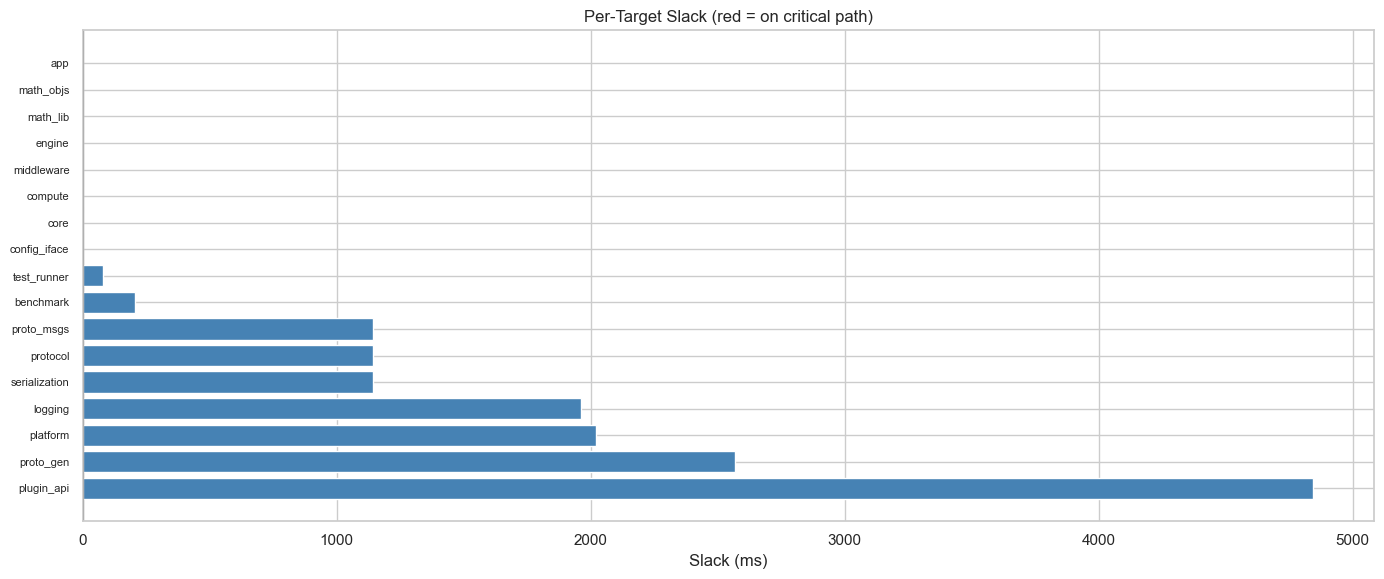

In [4]:
# Forward pass: earliest_start for each node (build order = reversed topo)
earliest_start = {}
for n in reversed(topo):
    deps = list(G.successors(n))
    earliest_start[n] = max((earliest_finish[d] for d in deps), default=0)

# Backward pass: latest_start and slack
# Process dependants before their dependencies = original topo order
# (topo puts dependants first since A -> B means A before B)
latest_finish = {}
latest_start = {}

for n in topo:  # dependants first
    w = G.nodes[n][weight_attr]
    dependants = list(G.predecessors(n))  # things that depend on n
    if not dependants:
        latest_finish[n] = cp_length  # root: nothing depends on it
    else:
        latest_finish[n] = min(latest_start[d] for d in dependants)
    latest_start[n] = latest_finish[n] - w

slack = {n: latest_start[n] - earliest_start[n] for n in G.nodes()}

# Build slack DataFrame — only include targets present in the graph
graph_nodes = set(G.nodes())
slack_df = target_df[target_df['cmake_target'].isin(graph_nodes)][['cmake_target', 'target_type']].copy()
slack_df['effective_weight_ms'] = slack_df['cmake_target'].map(
    lambda n: G.nodes[n].get(weight_attr, 0)
)
slack_df['earliest_start_ms'] = slack_df['cmake_target'].map(earliest_start)
slack_df['earliest_finish_ms'] = slack_df['cmake_target'].map(earliest_finish)
slack_df['latest_start_ms'] = slack_df['cmake_target'].map(latest_start)
slack_df['slack_ms'] = slack_df['cmake_target'].map(slack)
slack_df['on_critical_path'] = slack_df['slack_ms'].abs() < 1
slack_df = slack_df.sort_values('slack_ms')

print(f"Zero-slack (critical) targets: {slack_df['on_critical_path'].sum()}")
print(f"Slack range: {slack_df['slack_ms'].min():.0f} – {slack_df['slack_ms'].max():.0f} ms")
display(slack_df)

# Bar chart: targets sorted by slack
fig, ax = plt.subplots(figsize=(14, max(4, len(slack_df) * 0.35)))
colors = ['crimson' if s < 1 else 'steelblue' for s in slack_df['slack_ms']]
ax.barh(range(len(slack_df)), slack_df['slack_ms'].values, color=colors)
ax.set_yticks(range(len(slack_df)))
ax.set_yticklabels(slack_df['cmake_target'].values, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Slack (ms)')
ax.set_title('Per-Target Slack (red = on critical path)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Codegen on Critical Path

Identify codegen steps on the critical path — high-priority optimisation targets.


Codegen targets total:            1
Codegen targets on critical path: 0
Zero-slack codegen targets:       0

No codegen targets on the critical path.


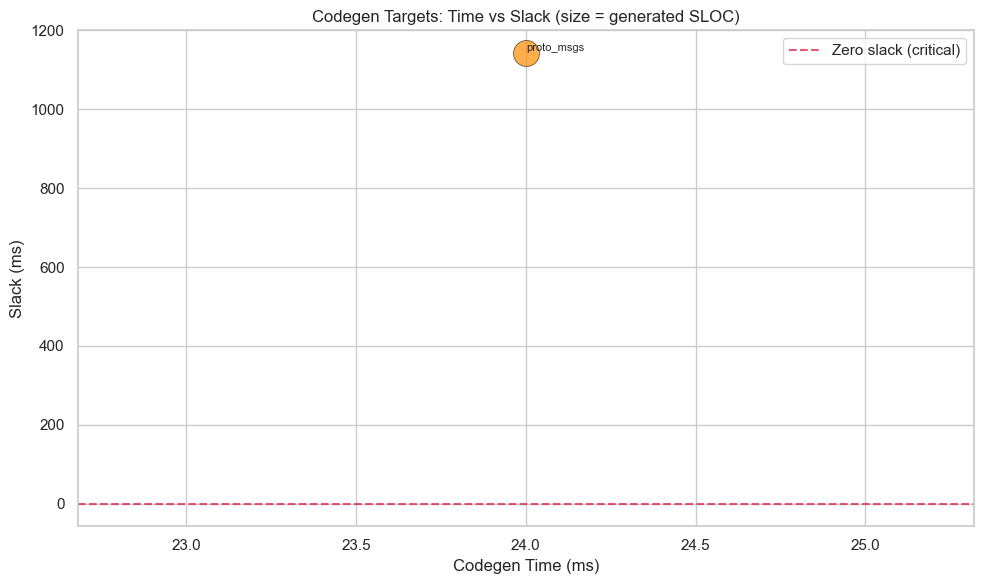

In [5]:
# Identify codegen targets and their relationship to the critical path
codegen_targets = target_df[target_df['codegen_time_ms'] > 0][
    ['cmake_target', 'codegen_time_ms', 'compile_time_max_ms',
     'codegen_file_count', 'code_lines_generated']
].copy()

codegen_on_cp = codegen_targets[codegen_targets['cmake_target'].isin(cp_set)].copy()
codegen_on_cp['slack_ms'] = codegen_on_cp['cmake_target'].map(slack)

zero_slack_codegen = codegen_targets[
    codegen_targets['cmake_target'].map(lambda n: abs(slack.get(n, 999)) < 1)
]

print(f"Codegen targets total:            {len(codegen_targets)}")
print(f"Codegen targets on critical path: {len(codegen_on_cp)}")
print(f"Zero-slack codegen targets:       {len(zero_slack_codegen)}")

if not codegen_on_cp.empty:
    cp_codegen_ms = codegen_on_cp['codegen_time_ms'].sum()
    print(f"\nCodegen time on critical path: {cp_codegen_ms:,} ms "
          f"({cp_codegen_ms / cp_length:.1%} of CP length)")
    print("\nCodegen targets on the critical path (high-priority optimisation targets):")
    display(codegen_on_cp)
else:
    print("\nNo codegen targets on the critical path.")

# Scatter: codegen_time_ms vs slack, size = code_lines_generated
if not codegen_targets.empty:
    plot_cg = codegen_targets.copy()
    plot_cg['slack_ms'] = plot_cg['cmake_target'].map(slack)

    fig, ax = plt.subplots(figsize=(10, 6))
    sizes = plot_cg['code_lines_generated'].clip(lower=1) / plot_cg['code_lines_generated'].max() * 300 + 50
    ax.scatter(plot_cg['codegen_time_ms'], plot_cg['slack_ms'],
               s=sizes, color='darkorange', alpha=0.7, edgecolors='black', linewidths=0.5)
    for _, row in plot_cg.iterrows():
        ax.annotate(row['cmake_target'], (row['codegen_time_ms'], row['slack_ms']),
                    fontsize=8, ha='left', va='bottom')
    ax.axhline(0, color='crimson', linestyle='--', alpha=0.7, label='Zero slack (critical)')
    ax.set_xlabel('Codegen Time (ms)')
    ax.set_ylabel('Slack (ms)')
    ax.set_title('Codegen Targets: Time vs Slack (size = generated SLOC)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Critical Path Visualisation

DAG with critical path highlighted, codegen targets distinct.


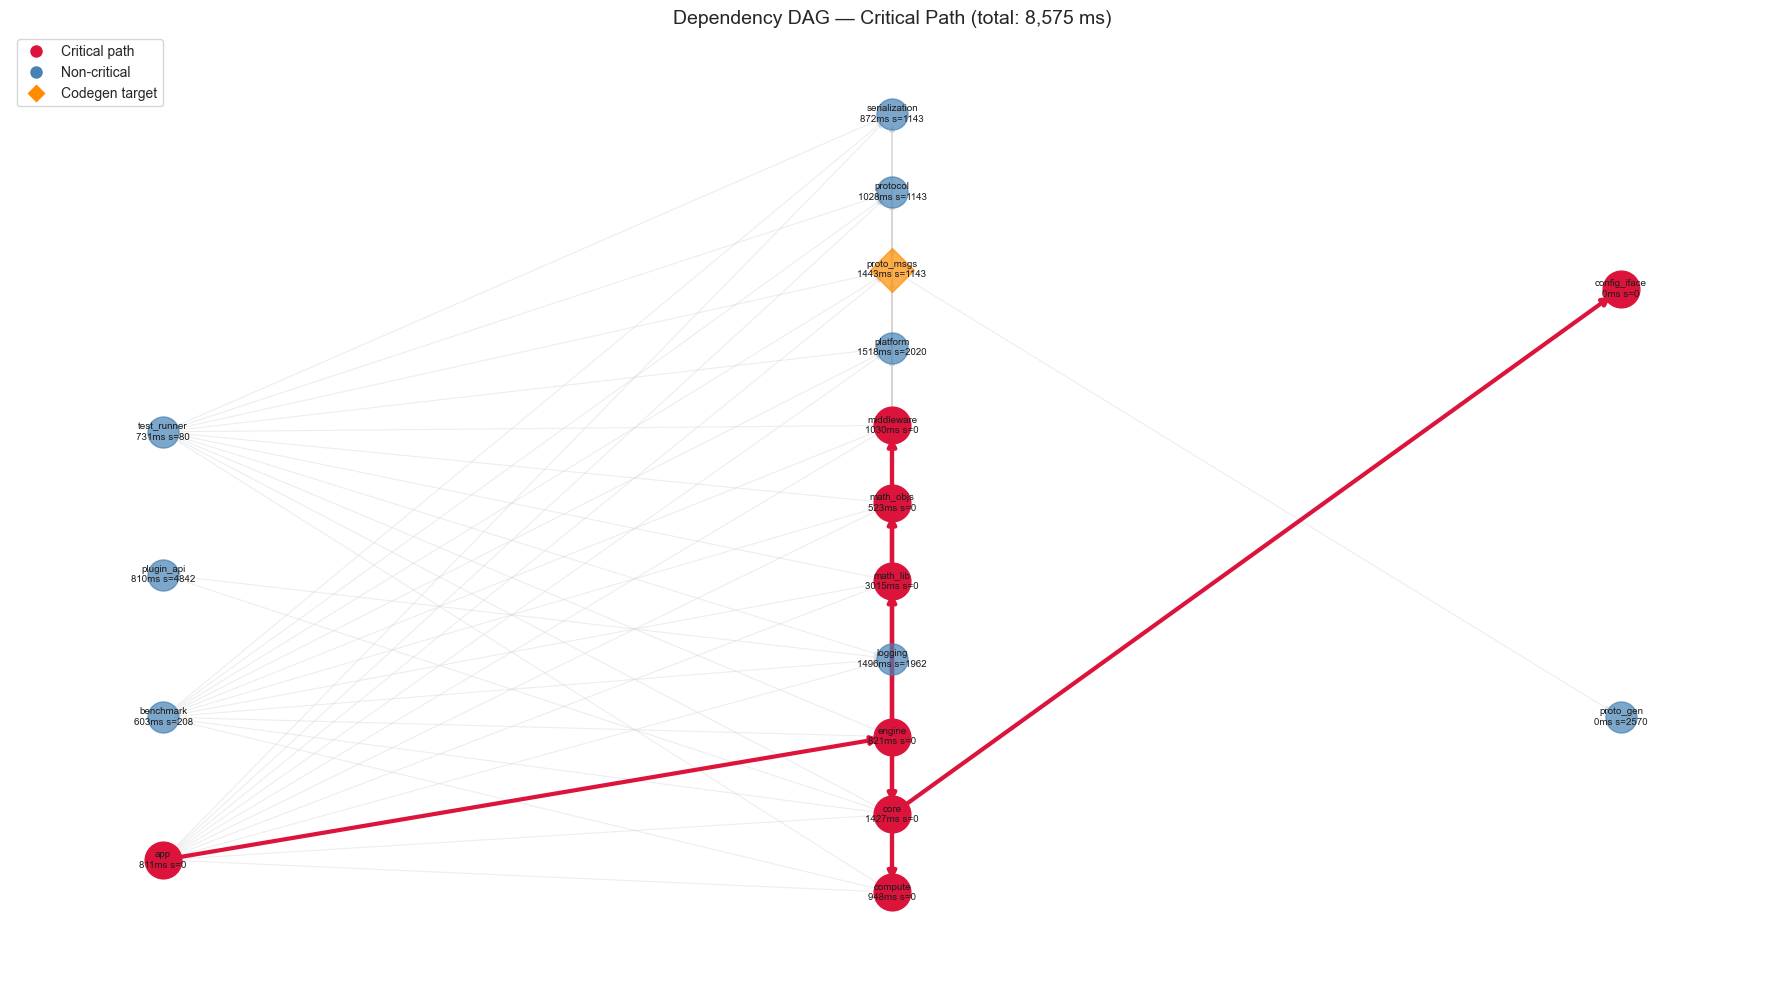

In [6]:
# Hierarchical layout: x = topological depth, y = spread within level
pos = {}
depth_groups = target_df.groupby('topological_depth')['cmake_target'].apply(list)
max_depth = int(target_df['topological_depth'].max()) if not target_df['topological_depth'].empty else 1

for depth, members in depth_groups.items():
    n = len(members)
    for i, t in enumerate(members):
        if t in G:
            pos[t] = (depth / max(max_depth, 1), (i + 0.5) / n)

# Classify nodes
codegen_set = set(target_df[target_df['codegen_time_ms'] > 0]['cmake_target'])
non_codegen_normal = [n for n in G.nodes() if n not in cp_set and n not in codegen_set and n in pos]
non_codegen_cp = [n for n in G.nodes() if n in cp_set and n not in codegen_set and n in pos]
codegen_normal = [n for n in G.nodes() if n not in cp_set and n in codegen_set and n in pos]
codegen_cp = [n for n in G.nodes() if n in cp_set and n in codegen_set and n in pos]

# Critical path edges
cp_edge_set = set()
for i in range(len(cp_nodes) - 1):
    u, v = cp_nodes[i], cp_nodes[i + 1]
    if G.has_edge(u, v):
        cp_edge_set.add((u, v))
    elif G.has_edge(v, u):
        cp_edge_set.add((v, u))

cp_edges = [(u, v) for u, v in G.edges() if (u, v) in cp_edge_set]
non_cp_edges = [(u, v) for u, v in G.edges() if (u, v) not in cp_edge_set]

fig, ax = plt.subplots(figsize=(18, 10))

nx.draw_networkx_edges(G, pos, edgelist=non_cp_edges, edge_color='lightgrey',
                       arrows=True, ax=ax, width=0.8, alpha=0.4, arrowsize=8)
nx.draw_networkx_edges(G, pos, edgelist=cp_edges, edge_color='crimson',
                       arrows=True, ax=ax, width=3, arrowsize=12)

nx.draw_networkx_nodes(G, pos, nodelist=non_codegen_normal, node_color='steelblue',
                       node_size=500, ax=ax, alpha=0.7)
nx.draw_networkx_nodes(G, pos, nodelist=non_codegen_cp, node_color='crimson',
                       node_size=700, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=codegen_normal, node_color='darkorange',
                       node_shape='D', node_size=500, ax=ax, alpha=0.7)
nx.draw_networkx_nodes(G, pos, nodelist=codegen_cp, node_color='darkorange',
                       node_shape='D', node_size=700, ax=ax, edgecolors='crimson', linewidths=3)

# Labels: target name, weight, slack
labels = {}
for n in G.nodes():
    if n in pos:
        w = G.nodes[n].get(weight_attr, 0)
        s = int(slack.get(n, 0))
        labels[n] = f"{n}\n{w}ms s={s}"
nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=10,
           label='Critical path'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10,
           label='Non-critical'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='darkorange', markersize=10,
           label='Codegen target'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.set_title(f'Dependency DAG — Critical Path (total: {cp_length:,} ms)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Bottleneck Ranking

Rank targets by critical path contribution. Separate codegen vs compilation.


=== Overall Bottleneck Ranking (top 10) ===


,cmake_target,target_type,codegen_time_ms,compile_time_max_ms,compile_time_sum_ms,archive_time_ms,link_time_ms,effective_weight_ms,slack_ms,on_critical_path,rank
6,math_lib,STATIC_LIBRARY,0,2969,5022,46,0,3015,0,True,1
3,core,STATIC_LIBRARY,0,1287,3361,140,0,1427,0,True,2
8,middleware,STATIC_LIBRARY,0,984,3482,46,0,1030,0,True,3
2,compute,STATIC_LIBRARY,0,906,1683,42,0,948,0,True,4
4,engine,STATIC_LIBRARY,0,783,783,38,0,821,0,True,5
0,app,EXECUTABLE,0,763,763,0,48,811,0,True,6
7,math_objs,OBJECT_LIBRARY,0,523,1022,0,0,523,0,True,7
18,config_iface,INTERFACE_LIBRARY,0,0,0,0,0,0,0,True,8
9,platform,STATIC_LIBRARY,0,1410,2391,108,0,1518,2020,False,9
5,logging,STATIC_LIBRARY,0,1370,2611,126,0,1496,1962,False,10



=== Codegen Bottleneck Ranking (1 targets) ===


,cmake_target,codegen_time_ms,compile_time_max_ms,effective_weight_ms,slack_ms,on_critical_path
12,proto_msgs,24,1338,1443,1143,False



=== Compilation Bottleneck Ranking (top 10 by max compile time) ===


,cmake_target,compile_time_max_ms,compile_time_sum_ms,effective_weight_ms,slack_ms
6,math_lib,2969,5022,3015,0
9,platform,1410,2391,1518,2020
5,logging,1370,2611,1496,1962
12,proto_msgs,1338,3977,1443,1143
3,core,1287,3361,1427,0
8,middleware,984,3482,1030,0
13,protocol,938,1637,1028,1143
2,compute,906,1683,948,0
4,engine,783,783,821,0
14,serialization,775,1459,872,1143


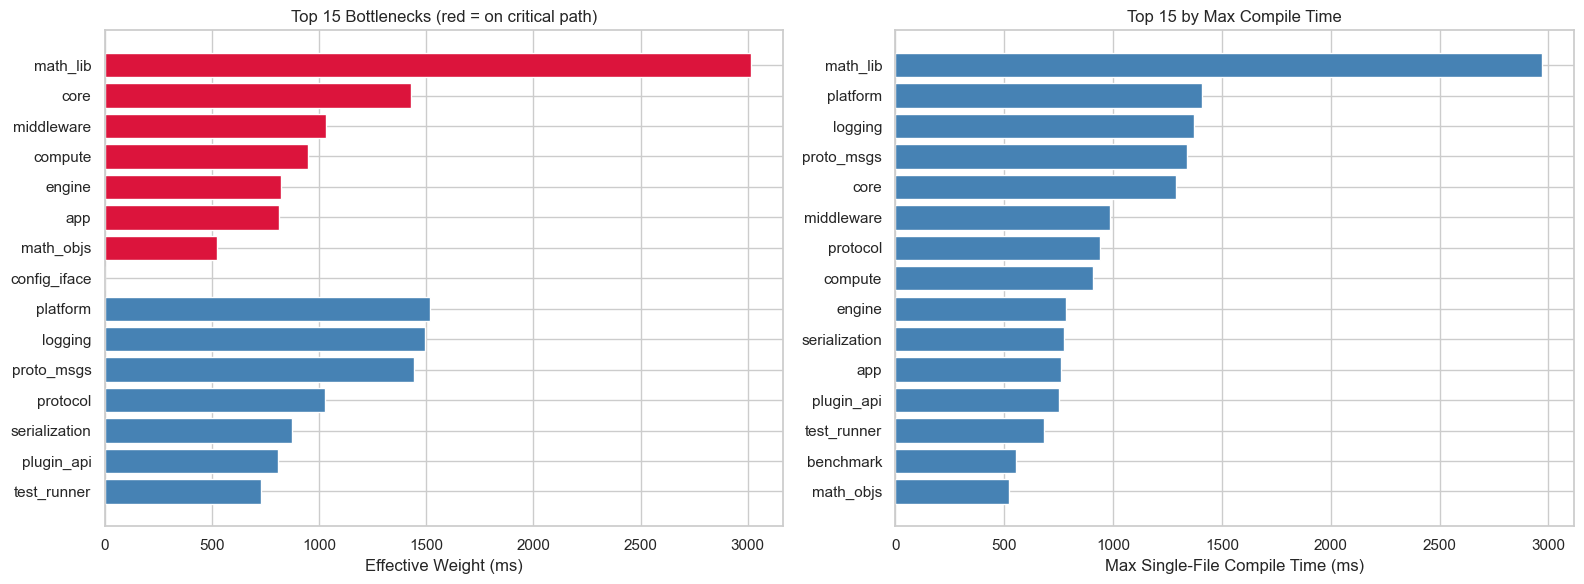

In [7]:
# Overall bottleneck ranking: critical path targets first, then by effective weight
# Filter to targets in the graph (excludes IMPORTED targets like Python3::Interpreter)
ranking_df = target_df[target_df['cmake_target'].isin(graph_nodes)][
    ['cmake_target', 'target_type', 'codegen_time_ms',
     'compile_time_max_ms', 'compile_time_sum_ms',
     'archive_time_ms', 'link_time_ms']
].copy()
ranking_df['effective_weight_ms'] = ranking_df['cmake_target'].map(
    lambda n: G.nodes[n].get(weight_attr, 0)
)
ranking_df['slack_ms'] = ranking_df['cmake_target'].map(slack)
ranking_df['on_critical_path'] = ranking_df['slack_ms'].abs() < 1
ranking_df = ranking_df.sort_values(['on_critical_path', 'effective_weight_ms'],
                                     ascending=[False, False])
ranking_df['rank'] = range(1, len(ranking_df) + 1)

print("=== Overall Bottleneck Ranking (top 10) ===")
display(ranking_df.head(10))

# Codegen bottleneck ranking
codegen_ranking = ranking_df[ranking_df['codegen_time_ms'] > 0].copy()
codegen_ranking = codegen_ranking.sort_values('codegen_time_ms', ascending=False)
print(f"\n=== Codegen Bottleneck Ranking ({len(codegen_ranking)} targets) ===")
display(codegen_ranking[['cmake_target', 'codegen_time_ms', 'compile_time_max_ms',
                          'effective_weight_ms', 'slack_ms', 'on_critical_path']])

# Compilation bottleneck ranking
compile_ranking = ranking_df[ranking_df['compile_time_max_ms'] > 0].sort_values(
    'compile_time_max_ms', ascending=False
)
print(f"\n=== Compilation Bottleneck Ranking (top 10 by max compile time) ===")
display(compile_ranking[['cmake_target', 'compile_time_max_ms', 'compile_time_sum_ms',
                          'effective_weight_ms', 'slack_ms']].head(10))

# Side-by-side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_overall = ranking_df.head(15).iloc[::-1]
colors_overall = ['crimson' if v else 'steelblue' for v in top_overall['on_critical_path']]
ax1.barh(top_overall['cmake_target'], top_overall['effective_weight_ms'], color=colors_overall)
ax1.set_xlabel('Effective Weight (ms)')
ax1.set_title('Top 15 Bottlenecks (red = on critical path)')

top_compile = compile_ranking.head(15).iloc[::-1]
ax2.barh(top_compile['cmake_target'], top_compile['compile_time_max_ms'], color='steelblue')
ax2.set_xlabel('Max Single-File Compile Time (ms)')
ax2.set_title('Top 15 by Max Compile Time')

plt.tight_layout()
plt.show()

## Build Parallelism Analysis

Ninja log start/end times: concurrent steps over time, parallelism efficiency ratio.


Build wall-clock time:       3,194 ms
Total CPU time:              33,131 ms
Critical path length:        8,575 ms
CP / wall-clock ratio:       2.68
Max concurrent steps:        13
Avg parallelism:             10.4 steps
Parallelism efficiency:      79.8%  (avg / max)
Low parallelism periods:     366 ms (11.5% of build)


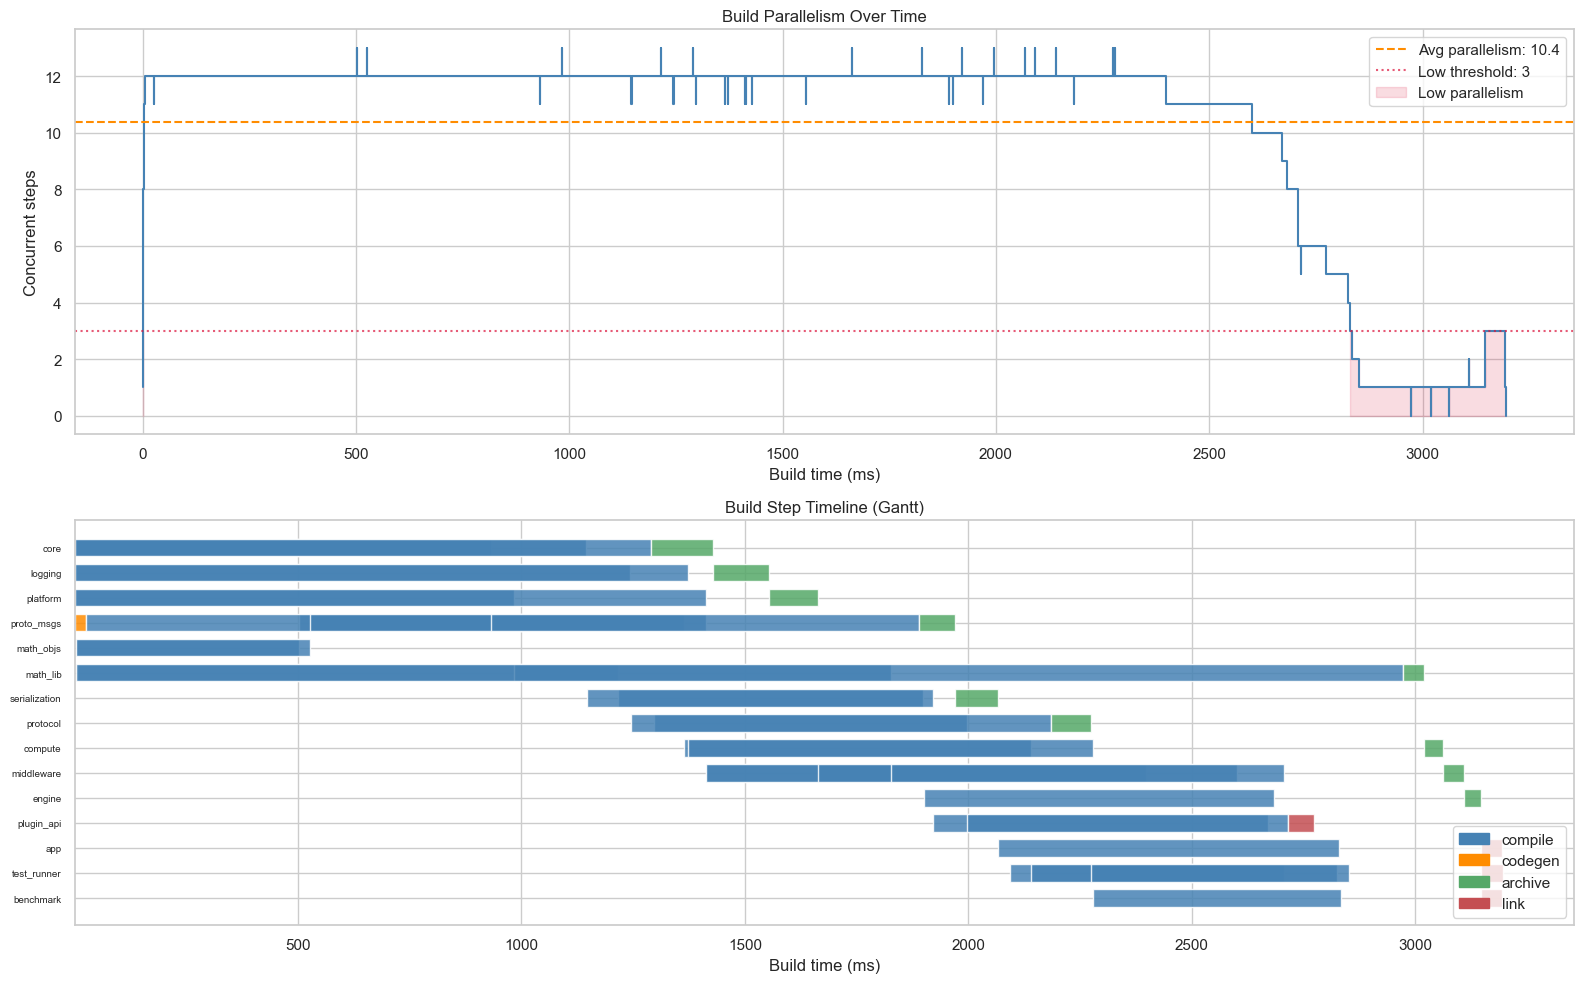

In [8]:
ninja_log = pd.read_csv(str(cfg.raw_data_dir / 'ninja_log.csv'))

# Filter out non-build steps (e.g. clean)
build_steps = ninja_log[ninja_log['step_type'] != 'other'].copy()

# Event-based concurrent step counting
events = pd.concat([
    build_steps[['start_ms']].rename(columns={'start_ms': 'time'}).assign(delta=1),
    build_steps[['end_ms']].rename(columns={'end_ms': 'time'}).assign(delta=-1),
]).sort_values('time').reset_index(drop=True)

events['concurrent'] = events['delta'].cumsum()

time_min = int(build_steps['start_ms'].min())
time_max = int(build_steps['end_ms'].max())
total_wall_ms = time_max - time_min
total_cpu_ms = int(build_steps['duration_ms'].sum())

# Time-weighted average parallelism
intervals = events.copy()
intervals['next_time'] = intervals['time'].shift(-1)
intervals['duration'] = intervals['next_time'] - intervals['time']
intervals = intervals.dropna(subset=['duration'])
intervals = intervals[intervals['duration'] > 0]

weighted_sum = (intervals['concurrent'] * intervals['duration']).sum()
avg_parallelism = weighted_sum / total_wall_ms if total_wall_ms > 0 else 0
max_concurrent = int(events['concurrent'].max())
efficiency = avg_parallelism / max_concurrent if max_concurrent > 0 else 0.0

# Low parallelism threshold
low_threshold = max(1, max_concurrent // 4)
bottleneck_intervals = intervals[intervals['concurrent'] <= low_threshold]
bottleneck_duration = bottleneck_intervals['duration'].sum()

# Compare with critical path
cp_ratio = cp_length / total_wall_ms if total_wall_ms > 0 else 0

print(f"Build wall-clock time:       {total_wall_ms:,} ms")
print(f"Total CPU time:              {total_cpu_ms:,} ms")
print(f"Critical path length:        {cp_length:,} ms")
print(f"CP / wall-clock ratio:       {cp_ratio:.2f}")
print(f"Max concurrent steps:        {max_concurrent}")
print(f"Avg parallelism:             {avg_parallelism:.1f} steps")
print(f"Parallelism efficiency:      {efficiency:.1%}  (avg / max)")
print(f"Low parallelism periods:     {bottleneck_duration:.0f} ms "
      f"({bottleneck_duration / total_wall_ms:.1%} of build)")

# --- Plot 1: Concurrent steps over time ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.step(events['time'], events['concurrent'], where='post', color='steelblue', linewidth=1.5)
ax1.axhline(avg_parallelism, color='darkorange', linestyle='--',
            label=f'Avg parallelism: {avg_parallelism:.1f}')
ax1.axhline(low_threshold, color='crimson', linestyle=':', alpha=0.7,
            label=f'Low threshold: {low_threshold}')
ax1.fill_between(events['time'], 0, events['concurrent'], step='post',
                 where=(events['concurrent'] <= low_threshold),
                 color='crimson', alpha=0.15, label='Low parallelism')
ax1.set_xlabel('Build time (ms)')
ax1.set_ylabel('Concurrent steps')
ax1.set_title('Build Parallelism Over Time')
ax1.legend()

# --- Plot 2: Gantt chart coloured by step_type ---
ax2 = axes[1]
step_colors = {'compile': 'steelblue', 'codegen': 'darkorange',
               'archive': '#55A868', 'link': '#C44E52'}

# Sort targets by start time for a cleaner Gantt
target_order = (build_steps.groupby('cmake_target')['start_ms'].min()
                .sort_values().index.tolist())
y_map = {t: i for i, t in enumerate(target_order)}

for _, row in build_steps.iterrows():
    y = y_map.get(row['cmake_target'], 0)
    ax2.barh(y, row['end_ms'] - row['start_ms'], left=row['start_ms'],
             height=0.7, color=step_colors.get(row['step_type'], 'grey'), alpha=0.85)

ax2.set_yticks(list(y_map.values()))
ax2.set_yticklabels(list(y_map.keys()), fontsize=7)
ax2.set_xlabel('Build time (ms)')
ax2.set_title('Build Step Timeline (Gantt)')
ax2.invert_yaxis()

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=s) for s, c in step_colors.items()]
ax2.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()